imports and reloading imports 

In [ ]:
from .modules.comment_extraction import api_setup, extract_comments
from .modules.comment_class import RawComment
from .modules.mongo_code import mongo_connect, get_collection, insert_comments, convert_df_to_list, load_collection_to_df, insert_df
from .modules.comment_preprocessing import preprocess_df
from .modules.processing import spacy_setup, extract_entities_df, extract_keywords_df, add_sentiment_df
from .modules.plots import sentiment_bar, sentiment_pie

______________________________________________________________________________________________________________________

general functions for api and mongo setup

In [ ]:
youtube_api = api_setup()
client = mongo_connect()
comments_db = client["comments_db"]
meta_db = client['metadata_db']
raw_comments = get_collection(comments_db, "raw_comments")
preprocessed_comments = get_collection(comments_db, "preprocssed_comments")
meta_data = get_collection(meta_db,"meta_data")
nlp = spacy_setup()

loaded youtube api
connected to mongodb at mongodb://localhost:27017/


In [ ]:
comments_db = client["comments_db"]
meta_db = client['metadata_db']
raw_comments = get_collection(comments_db, "raw_comments")
preprocessed_comments = get_collection(comments_db, "preprocssed_comments")
meta_data = get_collection(meta_db,"meta_data")
nlp = spacy_setup()

eg video raw comment extraction

In [55]:
video = "Y8yTY_7w3KA"

df1 = extract_comments(youtube_api,video)

df1.head()

Video Y8yTY_7w3KA: collected 129 rows so far
Video Y8yTY_7w3KA: collected 256 rows so far
Video Y8yTY_7w3KA: collected 502 rows so far


KeyboardInterrupt: 

In [ ]:
raw_comments_list = convert_df_to_list(df1)
inserted_comments = insert_comments(raw_comments, raw_comments_list)

connected to mongodb at mongodb://localhost:27017/
inserted 1031 new comment(s)


eg preprocessing, mongo retrieval and insertion

In [68]:
df_raw = load_collection_to_df(raw_comments)
df_clean = preprocess_df(df_raw)
# print(df_clean.columns.tolist())
# preprocessed_comments.delete_many({})

loaded 1031 documents from raw_comments
Final number of comments after cleaning: 959
Comments removed: 72


In [69]:
insert_df(preprocessed_comments, df_clean)

inserted 959 document(s) into preprocssed_comments


959

metadeta extraction and ner

In [70]:
df = load_collection_to_df(preprocessed_comments)

df = extract_entities_df(df,nlp)
df = extract_keywords_df(df)
df = add_sentiment_df(df)

df[["comment_id", "clean_text", "entities", "keywords", "sentiment_score", "sentiment"]].head(20)
print(df["sentiment"].value_counts())


loaded 959 documents from preprocssed_comments
TF-IDF matrix shape: (959, 1240)
sentiment
Positive    508
Negative    226
Neutral     225
Name: count, dtype: int64


In [77]:
df[df["entities"].apply(len) > 0][["comment_id", "clean_text", "entities"]].head(20)

,comment_id,clean_text,entities
0,UgzjI6TjvTQiaNdFJDh4AaABAg,Note that contrary to the first info and contr...,"[BYD, Germany, 02:35 Sporty, RWD, AWD, 04:19 S..."
2,UgzjI6TjvTQiaNdFJDh4AaABAg.9voUleYQpWB9vpI9k1jApB,Tammy AI is without a job now.,[Tammy AI]
4,UgzjI6TjvTQiaNdFJDh4AaABAg.9voUleYQpWB9wBY-12Xroy,What separate a good and bad BEV is the heat m...,"[Octovalve, Tesla]"
5,UgzjI6TjvTQiaNdFJDh4AaABAg.9voUleYQpWB9x4NCNpcFl3,I take it from your review that the Seal drive...,[Seal]
8,UgzMJoPNaZIT3ogzwiB4AaABAg,"Europe also was a lot of money, but we prefer ...",[Europe]
9,UgxfIDxJdGUsx8GV8_p4AaABAg,BYD is like the Kia lmao..its not all that one...,"[BYD, Kia]"
10,UgyySGMqY0cmd-2mU2V4AaABAg,1:29 that sounds so comforting & magical not s...,[Canada]
16,UgyeG4uZ7LOLWmGX4yt4AaABAg,So autogefühl... I respect you guys a lot. Giv...,[German]
18,UgyMNQns2ZsivPlpPpd4AaABAg,Not for me! The Seal looks nice and may be com...,[Tesla]
19,Ugydd3xvC7bTsJMq8hl4AaABAg,The interior puts the Model 3 to shame.,[the Model 3]


In [78]:
insert_df(meta_data, df)

skipped 959 duplicate(s)
inserted 0 document(s) into meta_data


0

data representation

loaded 959 documents from meta_data


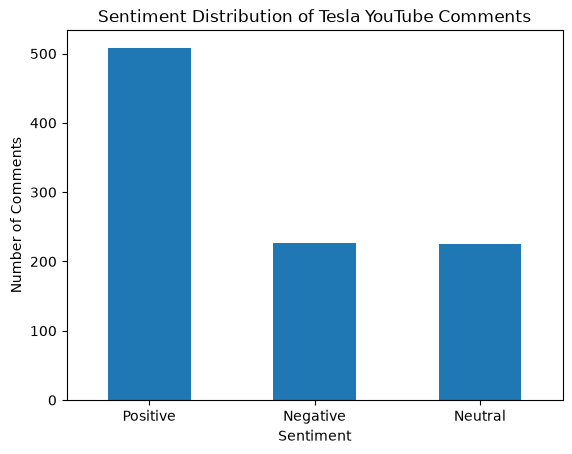

In [84]:
df = load_collection_to_df(meta_data)
sentiment_counts = df["sentiment"].value_counts()

sentiment_bar(sentiment_counts)

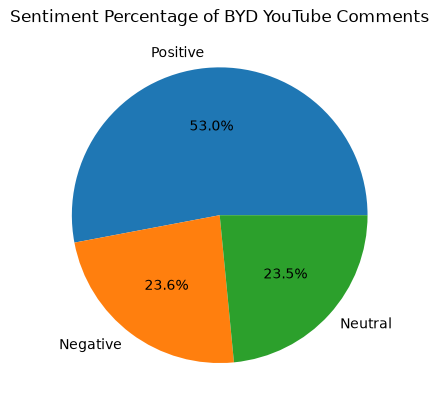

In [89]:
sentiment_pie(sentiment_counts)